In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**IMPORTATION DES DIFFERENTES BIBLIOTHEQUE**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import warnings
warnings.filterwarnings('ignore')


# Configuration pour les graphiques

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. CHARGEMENT ET EXPLORATION DES DONNÉES

**ANALYSE DU CHURN BANCAIRE**

In [5]:
df = pd.read_csv("/content/drive/MyDrive/donnees_churn_bancaire.csv")

Apercu des données

In [8]:
df.head()

,id_client,score_credit,age,anciennete,solde,nb_produits,carte_credit,membre_actif,salaire_estime,pays,genre,churn
0,1,452,71,7,210647.09,2,0,1,127809.06,Allemagne,Femme,0
1,2,785,30,4,201375.78,2,1,1,117649.40,France,Homme,1
2,3,698,36,5,182768.97,2,0,0,141257.00,France,Femme,0
3,4,620,46,6,115807.41,4,1,1,68520.92,Allemagne,Femme,0
4,5,456,20,3,80984.78,2,1,1,24974.34,Allemagne,Homme,1


INFORMATION SUR MES DONNEES

In [9]:
print(f"Nombre de lignes: {df.shape[0]}")
print(f"Nombre de colonnes: {df.shape[1]}")
print(f"\nTypes de données:")
print(df.dtypes)

Nombre de lignes: 10000
Nombre de colonnes: 12

Types de données:
id_client           int64
score_credit        int64
age                 int64
anciennete          int64
solde             float64
nb_produits         int64
carte_credit        int64
membre_actif        int64
salaire_estime    float64
pays               object
genre              object
churn               int64
dtype: object


VALEURS MANQUANTES

In [11]:
# Ici Je verifie si mon dataset possede des valeus manquantes
print(df.isnull().sum())

id_client         0
score_credit      0
age               0
anciennete        0
solde             0
nb_produits       0
carte_credit      0
membre_actif      0
salaire_estime    0
pays              0
genre             0
churn             0
dtype: int64


In [ ]:
# Il n'y a donc pas de valeurs manquantes dans mes données.

**STATISTIQUES DESCRIPTIVES**

In [13]:
df.describe()

,id_client,score_credit,age,anciennete,solde,nb_produits,carte_credit,membre_actif,salaire_estime,churn
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,599.809200,48.343400,6.993600,127060.403476,2.501800,0.697100,0.794600,107874.448489,0.430500
std,2886.89568,144.393617,17.883217,4.366058,71963.861090,1.112079,0.459535,0.404014,53144.908589,0.495171
min,1.00000,350.000000,18.000000,0.000000,12.030000,1.000000,0.000000,0.000000,15001.560000,0.000000
25%,2500.75000,475.000000,33.000000,3.000000,65403.980000,2.000000,0.000000,1.000000,62764.892500,0.000000
50%,5000.50000,600.000000,48.000000,7.000000,128009.910000,3.000000,1.000000,1.000000,108132.965000,0.000000
75%,7500.25000,726.250000,64.000000,11.000000,188272.430000,3.000000,1.000000,1.000000,153951.710000,1.000000
max,10000.00000,849.000000,79.000000,14.000000,249975.240000,4.000000,1.000000,1.000000,199988.840000,1.000000


#RÉPARTITION DU CHURN

In [16]:
churn_counts = df['churn'].value_counts()
print(churn_counts)
print(f"\nTaux de churn: {(churn_counts[1]/len(df)*100):.2f}%")

churn
0    5695
1    4305
Name: count, dtype: int64

Taux de churn: 43.05%


In [ ]:
# le jeu de donnée montre qu'on a 4305 clients sur 10000 qui sont parti de notre banque soit un TAUX de 43,05%.

# **2. ANALYSE EXPLORATOIRE**

CRÉATION DES VISUALISATIONS

✓ Graphique 1 sauvegardé: 1_repartition_churn.png


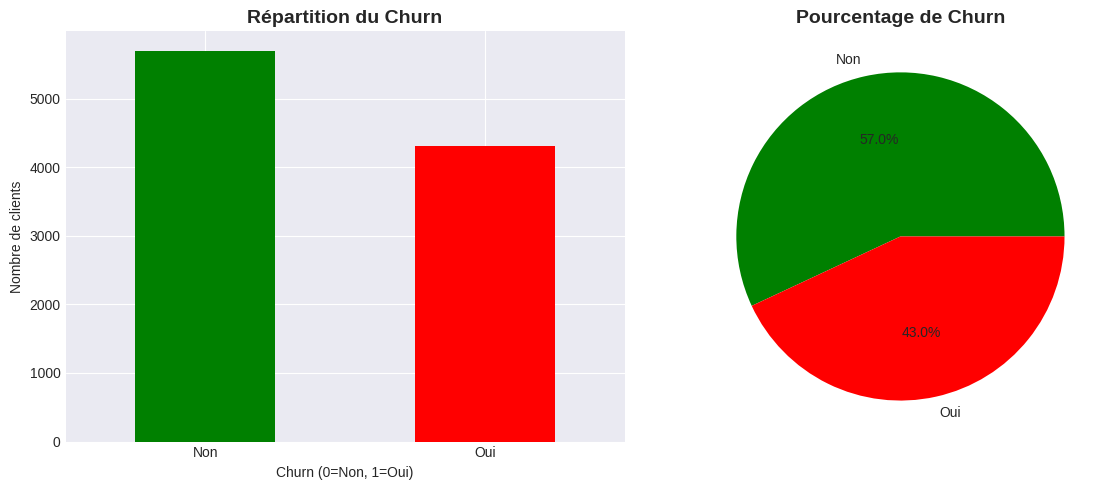

In [18]:
# Figure 1: Répartition du churn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['churn'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Répartition du Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0=Non, 1=Oui)')
axes[0].set_ylabel('Nombre de clients')
axes[0].set_xticklabels(['Non', 'Oui'], rotation=0)

# Pourcentage
churn_pct = df['churn'].value_counts(normalize=True) * 100
churn_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
               labels=['Non', 'Oui'], colors=['green', 'red'])
axes[1].set_title('Pourcentage de Churn', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('1_repartition_churn.png', dpi=300, bbox_inches='tight')
print("✓ Graphique 1 sauvegardé: 1_repartition_churn.png")

In [ ]:
# 43% de nos clients ont nous ont quitté , contre 57% qui restent. Ce taux est anormalement élevé : presque 1 client sur 2 part.

REPARTITION DU CHURN PAR PAYS

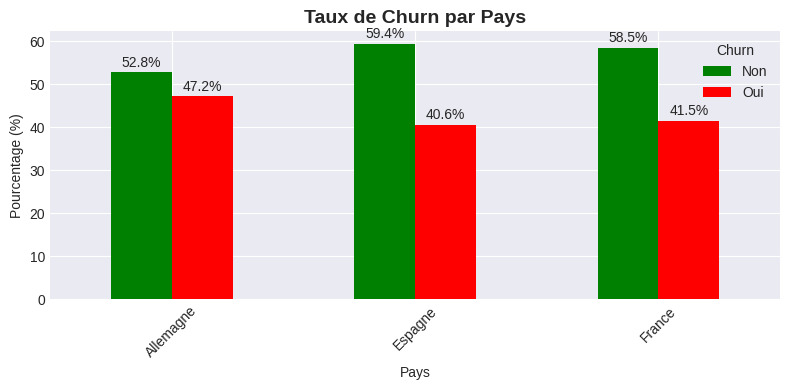

In [23]:

# Figure 2: Churn par pays
fig, ax = plt.subplots(figsize=(8, 4))

# Calcul des pourcentages
churn_by_country = pd.crosstab(df['pays'], df['churn'], normalize='index') * 100
bars = churn_by_country.plot(kind='bar', ax=ax, color=['green', 'red'])

# Titre et labels
ax.set_title('Taux de Churn par Pays', fontsize=14, fontweight='bold')
ax.set_xlabel('Pays')
ax.set_ylabel('Pourcentage (%)')
ax.legend(['Non', 'Oui'], title='Churn')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# ➤ Ajout des pourcentages sur chaque barre
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2)

# Mise en forme
plt.tight_layout()



In [24]:
print("L'Espagne affiche le taux de churn le plus élevé (40,6%) avec le plus grand écart de fidélisation, tandis que l'Allemagne et la France montrent des performances similaires autour de 42-47% de churn.")

L'Espagne affiche le taux de churn le plus élevé (40,6%) avec le plus grand écart de fidélisation, tandis que l'Allemagne et la France montrent des performances similaires autour de 42-47% de churn.


REPARTITION DU CHURN PAR GENRE

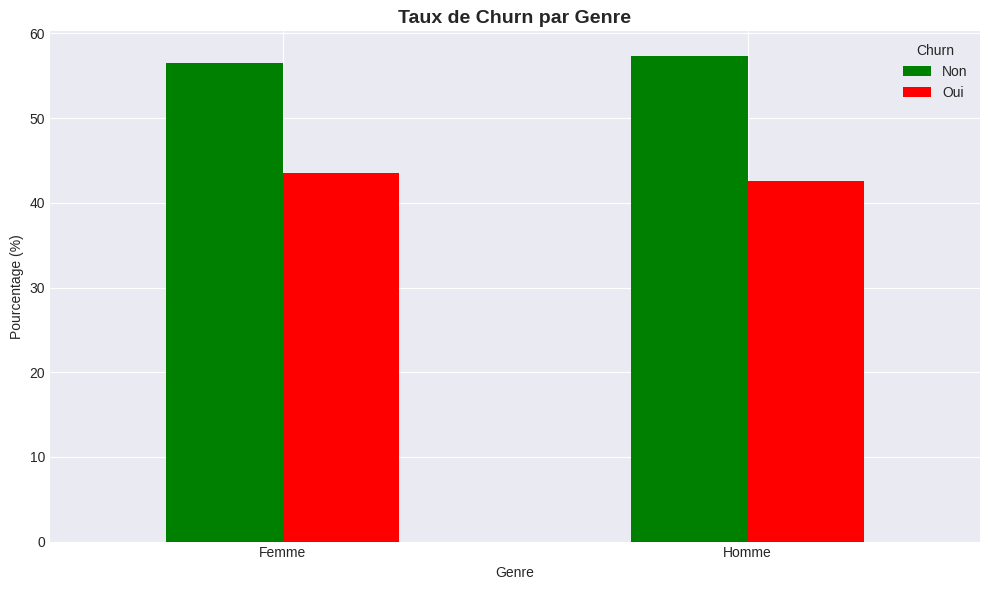

In [25]:
# Figure 3: Churn par genre
fig, ax = plt.subplots(figsize=(10, 6))
churn_by_gender = pd.crosstab(df['genre'], df['churn'], normalize='index') * 100
churn_by_gender.plot(kind='bar', ax=ax, color=['green', 'red'])
ax.set_title('Taux de Churn par Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Pourcentage (%)')
ax.legend(['Non', 'Oui'], title='Churn')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()

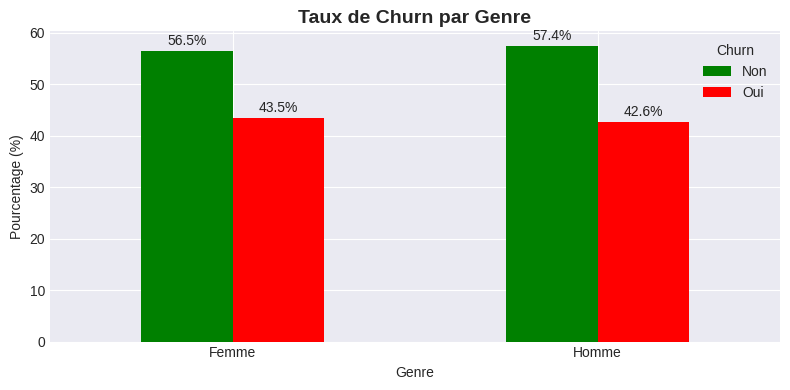

In [29]:
# Figure 3: Churn par genre
fig, ax = plt.subplots(figsize=(8, 4))

# Calcul des pourcentages
churn_by_gender = pd.crosstab(df['genre'], df['churn'], normalize='index') * 100

bars = churn_by_gender.plot(kind='bar', ax=ax, color=['green', 'red'])

ax.set_title('Taux de Churn par Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Pourcentage (%)')
ax.legend(['Non', 'Oui'], title='Churn')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2)

# Mise en forme
plt.tight_layout()


Le taux de churn est quasi identique entre hommes (42,6%) et femmes (43,5%), indiquant que le genre n'est pas un facteur discriminant dans l'attrition client

Distribution de l'âge selon le churn

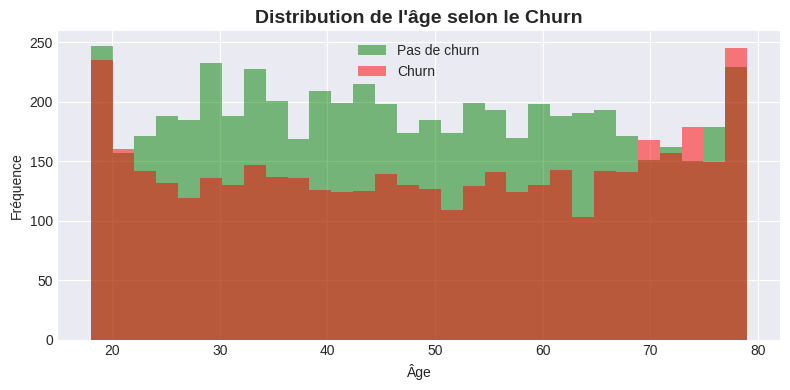

In [33]:
# Figure 4: Distribution de l'âge selon le churn
fig, ax = plt.subplots(figsize=(8, 4))
df[df['churn']==0]['age'].hist(bins=30, alpha=0.5, label='Pas de churn', color='green', ax=ax)
df[df['churn']==1]['age'].hist(bins=30, alpha=0.5, label='Churn', color='red', ax=ax)
ax.set_title('Distribution de l\'âge selon le Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Âge')
ax.set_ylabel('Fréquence')
ax.legend()
plt.tight_layout()

les clients très jeunes (autour de 20 ans) et seniors (75-80 ans) ont un taux de churn proportionnellement plus élevé.

#Churn par nombre de produits

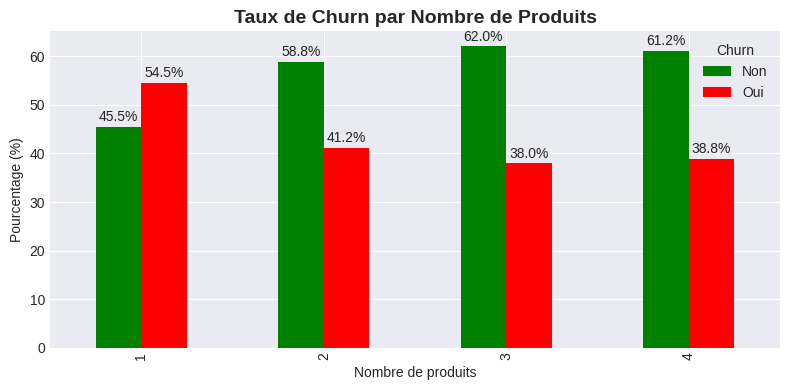

In [35]:
# Figure 5: Churn par nombre de produits
fig, ax = plt.subplots(figsize=(8, 4))

# Calcul des pourcentages
churn_by_products = pd.crosstab(df['nb_produits'], df['churn'], normalize='index') * 100

# Plot
bars = churn_by_products.plot(kind='bar', ax=ax, color=['green', 'red'])

# Titre et labels
ax.set_title('Taux de Churn par Nombre de Produits', fontsize=14, fontweight='bold')
ax.set_xlabel('Nombre de produits')
ax.set_ylabel('Pourcentage (%)')
ax.legend(['Non', 'Oui'], title='Churn')

# ➤ Ajout des pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2)

# Mise en forme
plt.tight_layout()



Les clients avec un seul produit ont le taux de churn le plus élevé (54,5%), tandis que ceux avec 3-4 produits sont les plus fidèles (38-39% de churn)

#Churn selon le statut de membre actif

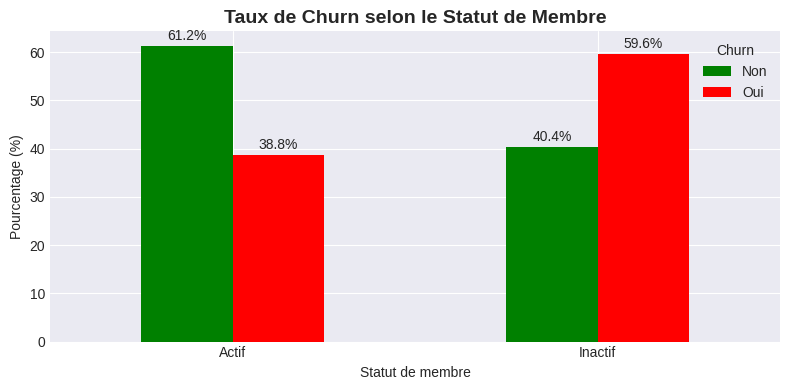

In [37]:
# Figure 6: Churn selon le statut de membre actif
fig, ax = plt.subplots(figsize=(8, 4))

# Mapping des labels
member_labels = {0: 'Inactif', 1: 'Actif'}
df_temp = df.copy()
df_temp['membre_actif_label'] = df_temp['membre_actif'].map(member_labels)

# Calcul des pourcentages
churn_by_member = pd.crosstab(df_temp['membre_actif_label'], df_temp['churn'], normalize='index') * 100

# Plot
bars = churn_by_member.plot(kind='bar', ax=ax, color=['green', 'red'])

# Titre & axes
ax.set_title('Taux de Churn selon le Statut de Membre', fontsize=14, fontweight='bold')
ax.set_xlabel('Statut de membre')
ax.set_ylabel('Pourcentage (%)')
ax.legend(['Non', 'Oui'], title='Churn')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# ➤ Ajout des pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2)

# Mise en forme
plt.tight_layout()



Les membres inactifs ont un taux de churn dramatiquement élevé (59,6%) comparé aux membres actifs (38,8%), révélant que l'engagement client est un indicateur clé de rétention à prioriser

#**Matrice de corrélation**

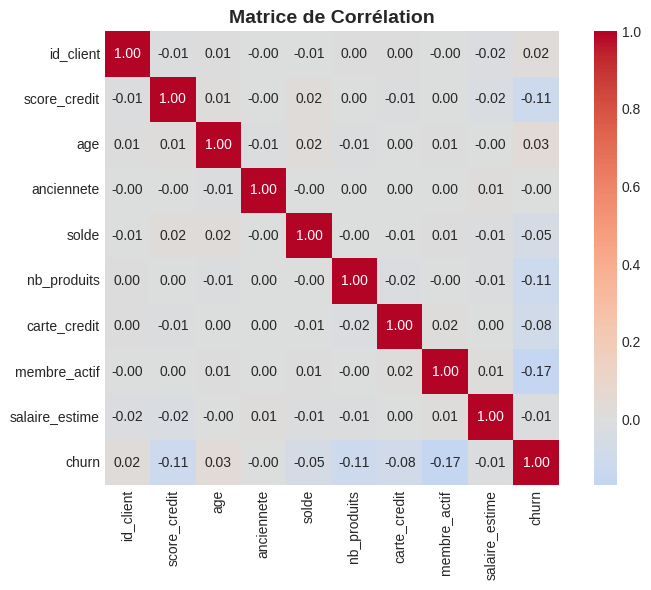

In [42]:
# Figure 7: Matrice de corrélation
fig, ax = plt.subplots(figsize=(8, 6))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()


# **3. PRÉPARATION DES DONNÉES POUR LA MODÉLISATION**

PRÉPARATION DES DONNÉES

In [48]:
# Encodage des variables catégorielles
df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, columns=['pays', 'genre'], drop_first=True)

# Séparation des features et de la cible
X = df_encoded.drop(['id_client', 'churn', 'age_group'], axis=1) # Removed 'age_group' here
y = df_encoded['churn']

print(f"Nombre de features: {X.shape[1]}")
print(f"Features: {list(X.columns)}")

# Division en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTaille d'entraînement: {X_train.shape[0]}")
print(f"Taille de test: {X_test.shape[0]}")
# Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Nombre de features: 11
Features: ['score_credit', 'age', 'anciennete', 'solde', 'nb_produits', 'carte_credit', 'membre_actif', 'salaire_estime', 'pays_Espagne', 'pays_France', 'genre_Homme']

Taille d'entraînement: 8000
Taille de test: 2000


# 4. **MODÉLISATION**

ENTRAÎNEMENT DES MODÈLES

In [49]:
# Dictionnaire pour stocker les résultats
results = {}

Modèle 1: Régression Logistique

In [50]:
# Modèle 1: Régression Logistique
print("\n1. Régression Logistique...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
results['Régression Logistique'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'roc_auc': roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
}
print("✓ Modèle entraîné")


1. Régression Logistique...
✓ Modèle entraîné


Modèle 2: Arbre de Décision

In [51]:
# Modèle 2: Arbre de Décision
print("\n2. Arbre de Décision...")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
results['Arbre de Décision'] = {
    'accuracy': accuracy_score(y_test, y_pred_dt),
    'precision': precision_score(y_test, y_pred_dt),
    'recall': recall_score(y_test, y_pred_dt),
    'f1': f1_score(y_test, y_pred_dt),
    'roc_auc': roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])
}
print("✓ Modèle entraîné")


2. Arbre de Décision...
✓ Modèle entraîné


Modèle 3: Random Forest

In [52]:
# Modèle 3: Random Forest
print("\n3. Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
}
print("✓ Modèle entraîné")



3. Random Forest...
✓ Modèle entraîné


# **5. ÉVALUATION DES MODÈLES**

**RÉSULTATS DES MODÈLES**

In [55]:
# Tableau comparatif
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print("\n COMPARAISON DES MODÈLES ")
results_df


 COMPARAISON DES MODÈLES 


,accuracy,precision,recall,f1,roc_auc
Régression Logistique,0.6245,0.5952,0.3995,0.4781,0.6436
Arbre de Décision,0.5950,0.5405,0.3949,0.4564,0.5752
Random Forest,0.6230,0.5884,0.4135,0.4857,0.6564


In [57]:
# Meilleur modèle
best_model = results_df['f1'].idxmax()
print(f"\n Meilleur modèle: {best_model} (F1-Score: {results_df.loc[best_model, 'f1']:.4f})")


 Meilleur modèle: Random Forest (F1-Score: 0.4857)


Comparaison des modèles

✓ Graphique 9 sauvegardé: 9_matrice_confusion.png


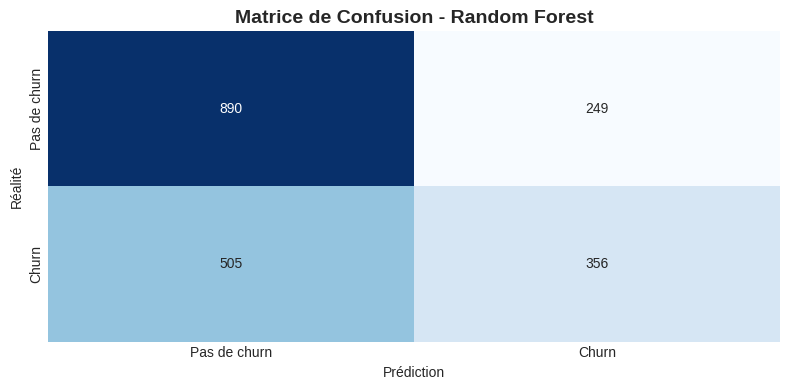

In [64]:
# Figure 9: Matrice de confusion pour le meilleur modèle (Random Forest)
fig, ax = plt.subplots(figsize=(8, 4))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('Matrice de Confusion - Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Prédiction')
ax.set_ylabel('Réalité')
ax.set_xticklabels(['Pas de churn', 'Churn'])
ax.set_yticklabels(['Pas de churn', 'Churn'])
plt.tight_layout()
plt.savefig('9_matrice_confusion.png', dpi=300, bbox_inches='tight')
print("✓ Graphique 9 sauvegardé: 9_matrice_confusion.png")


Importance des variables (Random Forest)

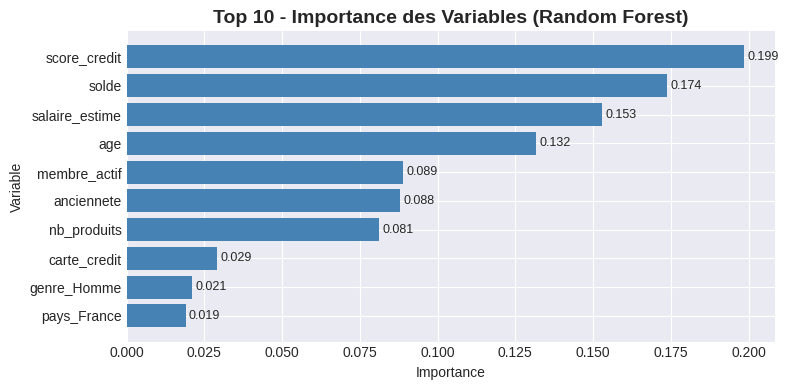

In [70]:
# Figure 10: Importance des variables (Random Forest)
fig, ax = plt.subplots(figsize=(8, 4))

# Tri + sélection Top 10
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True).tail(10)

# Plot
bars = ax.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')

# Titre et labels
ax.set_title('Top 10 - Importance des Variables (Random Forest)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('Variable')

# ➤ Ajout des valeurs sur les barres
for bar in bars:
    value = bar.get_width()
    ax.text(value + 0.001, bar.get_y() + bar.get_height()/2,
            f"{value:.3f}", va='center', fontsize=9)

# Mise en forme
plt.tight_layout()


**# 6. RAPPORT DÉTAILLÉ**

In [73]:
print("\n RAPPORT DE CLASSIFICATION (RANDOM FOREST)")
print(classification_report(y_test, y_pred_rf, target_names=['Pas de churn', 'Churn']))


 RAPPORT DE CLASSIFICATION (RANDOM FOREST)
              precision    recall  f1-score   support

Pas de churn       0.64      0.78      0.70      1139
       Churn       0.59      0.41      0.49       861

    accuracy                           0.62      2000
   macro avg       0.61      0.60      0.59      2000
weighted avg       0.62      0.62      0.61      2000



**# 7. PRÉDICTIONS SUR DE NOUVEAUX CLIENTS**

In [74]:
print("\n--- EXEMPLE DE PRÉDICTION ---")
# Prendre un client de l'ensemble de test
exemple_client = X_test.iloc[0:1]
print("\nCaractéristiques du client:")
print(exemple_client.T)

prediction = rf_model.predict(exemple_client)[0]
probabilite = rf_model.predict_proba(exemple_client)[0]

print(f"\nPrédiction: {'CHURN' if prediction == 1 else 'PAS DE CHURN'}")
print(f"Probabilité de churn: {probabilite[1]*100:.2f}%")
print(f"Probabilité de rester: {probabilite[0]*100:.2f}%")



--- EXEMPLE DE PRÉDICTION ---

Caractéristiques du client:
                     4125
score_credit          803
age                    28
anciennete              3
solde            224664.1
nb_produits             1
carte_credit            1
membre_actif            1
salaire_estime  126889.47
pays_Espagne        False
pays_France         False
genre_Homme         False

Prédiction: PAS DE CHURN
Probabilité de churn: 37.21%
Probabilité de rester: 62.79%
